In [1]:
import matplotlib.pyplot as plt

def plot_seirhd(df, params=None, title="SEIRHD Model Simulation"):
    """
    Plots the SEIRHD curves from the simulation dataframe.
    
    Args:
        df (pd.DataFrame): DataFrame containing the simulation stats.
        params (Params, optional): Simulation parameters (used for Title/N).
        title (str): Custom title for the plot.
    """
    # Define standard colors
    colors = {
        "S": "tab:blue",
        "E": "gold",
        "I0": "orange",
        "I1": "darkorange",
        "I2": "orangered",
        "R": "tab:green",
        "H": "tab:red",
        "D": "black"
    }

    plt.figure(figsize=(12, 6))

    # Aggregate Infectious states (Asymptomatic + Mild + Severe)
    # Check if columns exist to be safe, though your sim guarantees them
    if all(col in df.columns for col in ["I0", "I1", "I2"]):
        df["I_total"] = df["I0"] + df["I1"] + df["I2"]
        plt.plot(df["days"], df["I_total"], label="Infectious (Total)", color="orange", linewidth=2.5)
    
    # Plot individual curves
    if "S" in df.columns:
        plt.plot(df["days"], df["S"], label="Susceptible", color=colors["S"], linestyle="--", alpha=0.7)
    if "E" in df.columns:
        plt.plot(df["days"], df["E"], label="Exposed", color=colors["E"], linewidth=2)
    if "H" in df.columns:
        plt.plot(df["days"], df["H"], label="Hospitalized", color=colors["H"], linewidth=2)
    if "R" in df.columns:
        plt.plot(df["days"], df["R"], label="Recovered", color=colors["R"], linewidth=2)
    if "D" in df.columns:
        plt.plot(df["days"], df["D"], label="Dead", color=colors["D"], linewidth=2, linestyle="-.")

    # Dynamic Title
    if params:
        full_title = f"{title} (N={params.N})"
    else:
        full_title = title
        
    plt.xlabel("Days")
    plt.ylabel("Population Count")
    plt.title(full_title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# --- Example Usage ---
# Assuming 'sim' is your simulation object from the previous step:
# df = pd.DataFrame(sim.get_stats_df())
# df["days"] = df["time"] / 24  # Ensure time is converted to days
# plot_seirhd(df, params=params_ultra)

--- BENCHMARKING (N=5000, T=1440h) ---
Running Standard Model... 94.64 s


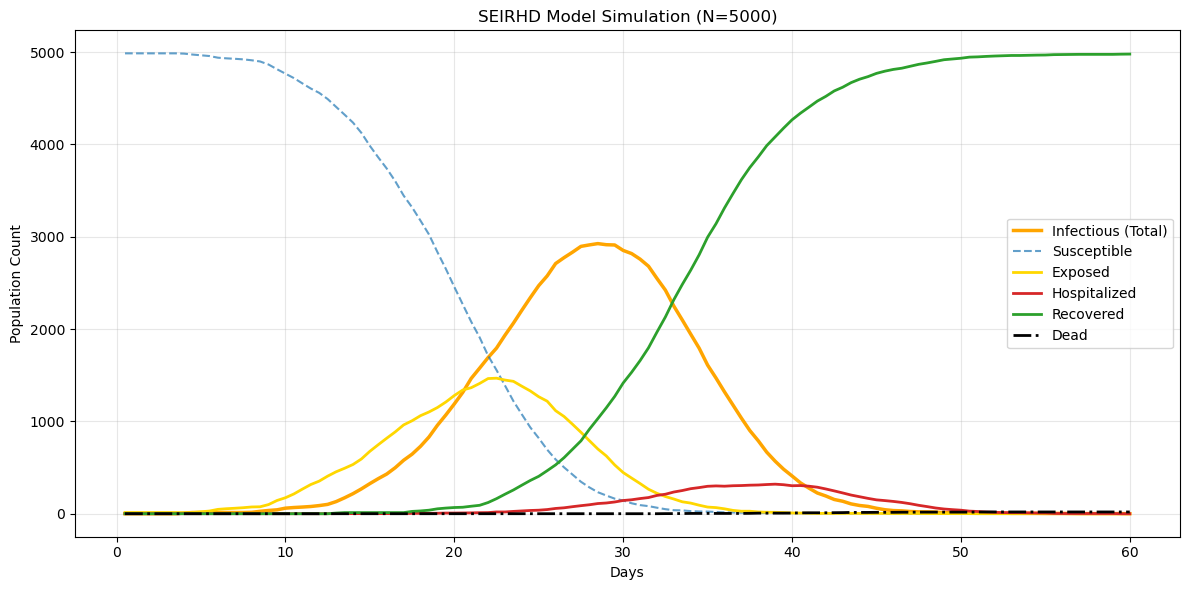

Running Optimized Model... 71.34 s


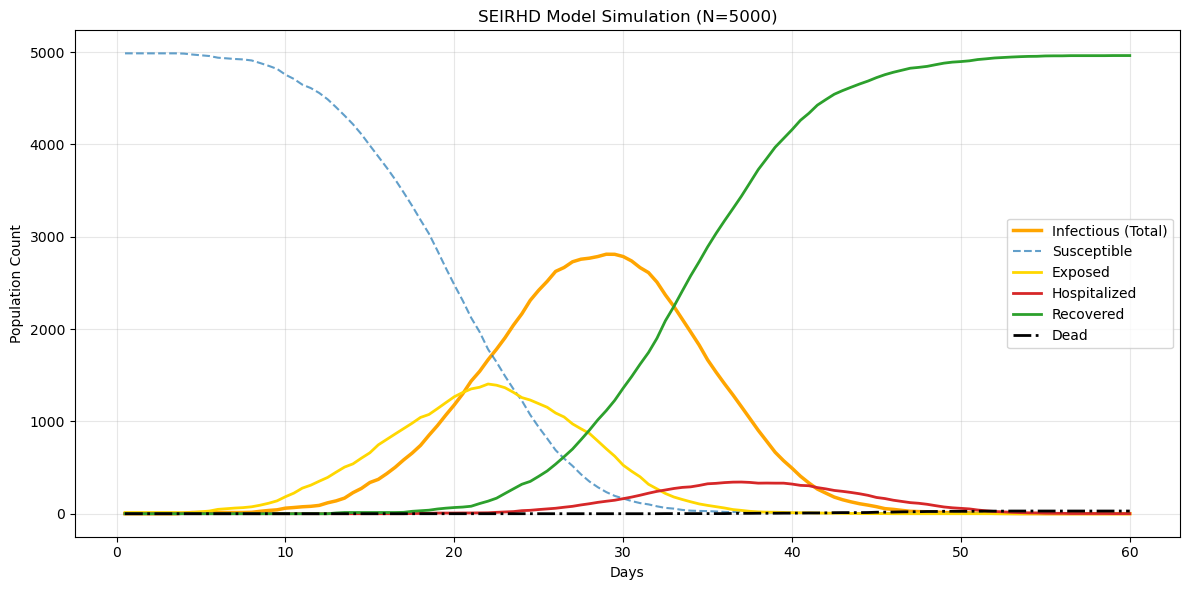

Running Final Model...     59.41 s


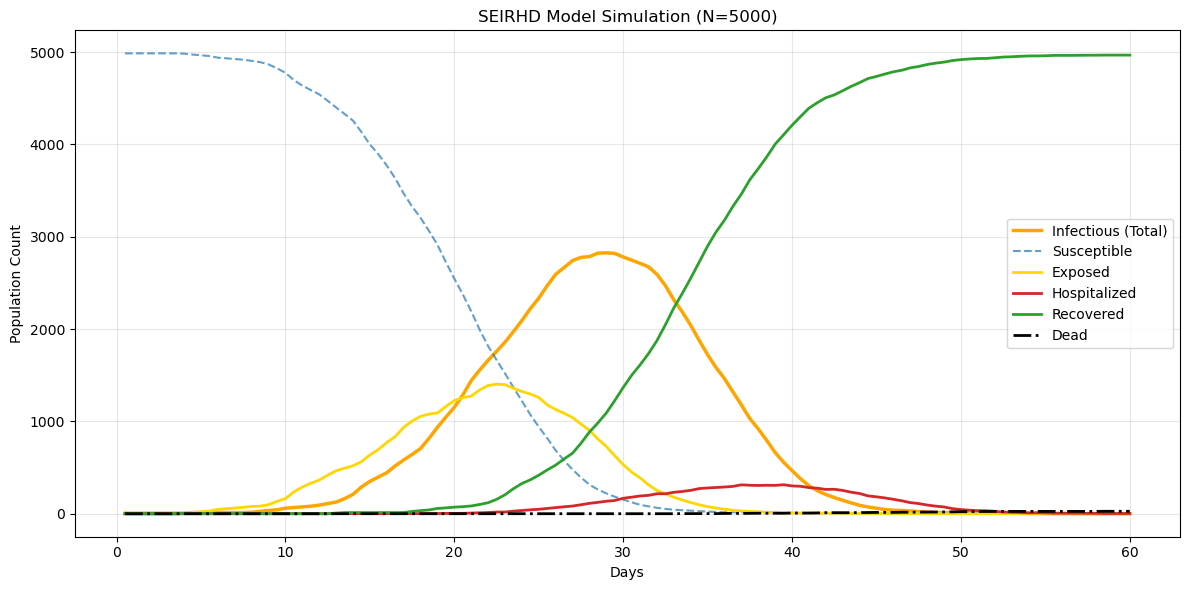

Running Ultra Model...     26.19 s


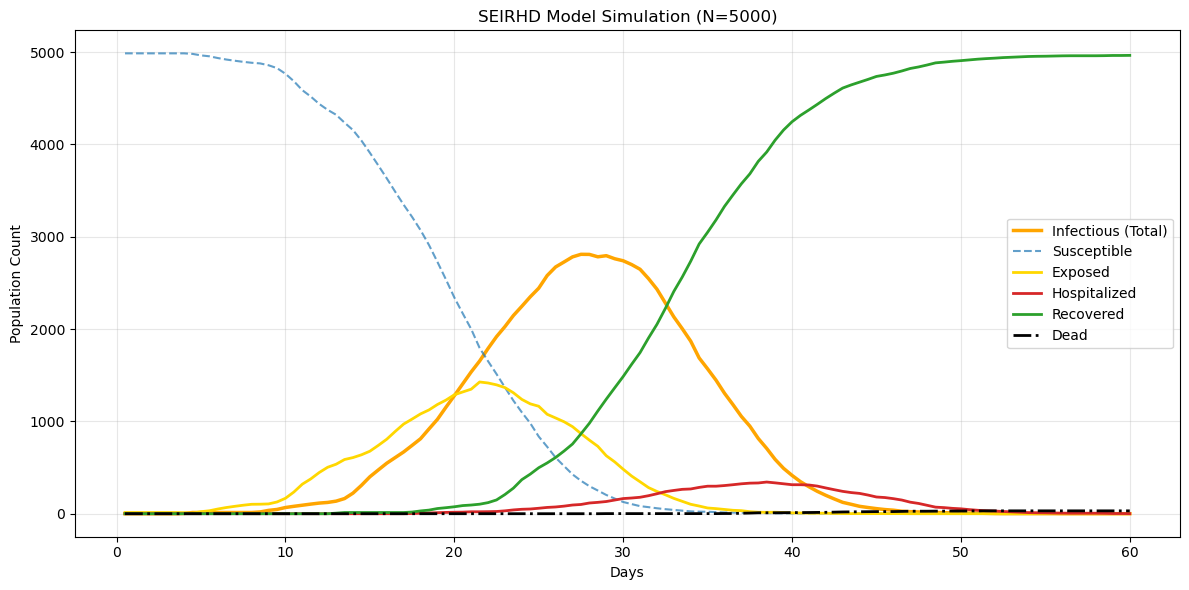


=== SUMMARY OF SPEEDUP (Baseline: Standard) ===
Optimized: 1.33x
Final:     1.59x
Ultra:     3.61x


In [2]:
import time
import pandas as pd
import matplotlib.pyplot as plt

# Import ALL four versions
# Ensure all files (infection_model.py, infection_model_opt.py, etc.) are in the same folder
import infection_model_1 as mod_std
import infection_model_opt as mod_opt
import infection_model_final as mod_final
import infection_model_ultra as mod_ultra

# --- Parameters ---
# Use a challenging load for clear differentiation
T_HOURS = 60 * 24  # 15 days
N_AGENTS = 5000

print(f"--- BENCHMARKING (N={N_AGENTS}, T={T_HOURS}h) ---")

# --- 1. Standard ---
print("Running Standard Model...", end=" ")
t0 = time.time()
params_std = mod_std.Params(
    T=T_HOURS, N=N_AGENTS, alpha=3, exposed=13,
    ratios=mod_std.AgentTypeRatio(retired=0.2, adult=0.6, child=0.2),
    schools=1, primary_care=5, hospitals=1, other_working_places=2, public_places=6,
)
sim = mod_std.Simulation(params=params_std, seed=42)
sim.init()
sim.run(dt=12.0)
t_std = time.time() - t0
print(f"{t_std:.2f} s")

df = pd.DataFrame(sim.get_stats_df())
df["days"] = df["time"] / 24  # Ensure time is converted to days
plot_seirhd(df, params=params_std)

# --- 2. Optimized (Deque/Slots) ---
print("Running Optimized Model...", end=" ")
t0 = time.time()
params_opt = mod_opt.Params(
    T=T_HOURS, N=N_AGENTS, alpha=3, exposed=13,
    ratios=mod_opt.AgentTypeRatio(retired=0.2, adult=0.6, child=0.2),
    schools=1, primary_care=5, hospitals=1, other_working_places=2, public_places=6,
)
sim = mod_opt.Simulation(params=params_opt, seed=42)
sim.init()
sim.run(dt=12.0)
t_opt = time.time() - t0
print(f"{t_opt:.2f} s")
df = pd.DataFrame(sim.get_stats_df())
df["days"] = df["time"] / 24  # Ensure time is converted to days
plot_seirhd(df, params=params_opt)

# --- 3. Final (Inc Stats/Event Slots) ---
print("Running Final Model...    ", end=" ")
t0 = time.time()
params_final = mod_final.Params(
    T=T_HOURS, N=N_AGENTS, alpha=3, exposed=13,
    ratios=mod_final.AgentTypeRatio(retired=0.2, adult=0.6, child=0.2),
    schools=1, primary_care=5, hospitals=1, other_working_places=2, public_places=6,
)
sim = mod_final.Simulation(params=params_final, seed=42)
sim.init()
sim.run(dt=12.0)
t_final = time.time() - t0
print(f"{t_final:.2f} s")
df = pd.DataFrame(sim.get_stats_df())
df["days"] = df["time"] / 24  # Ensure time is converted to days
plot_seirhd(df, params=params_final)

# --- 4. Ultra (Partitions/Sampling) ---
print("Running Ultra Model...    ", end=" ")
t0 = time.time()
params_ultra = mod_ultra.Params(
    T=T_HOURS, N=N_AGENTS, alpha=3, exposed=13,
    ratios=mod_ultra.AgentTypeRatio(retired=0.2, adult=0.6, child=0.2),
    schools=1, primary_care=5, hospitals=1, other_working_places=2, public_places=6,
)
sim = mod_ultra.Simulation(params=params_ultra, seed=42)
sim.init()
sim.run(dt=12.0)
t_ultra = time.time() - t0
print(f"{t_ultra:.2f} s")
df = pd.DataFrame(sim.get_stats_df())
df["days"] = df["time"] / 24  # Ensure time is converted to days
plot_seirhd(df, params=params_ultra)
# --- Summary ---
print("\n=== SUMMARY OF SPEEDUP (Baseline: Standard) ===")
print(f"Optimized: {t_std / t_opt:.2f}x")
print(f"Final:     {t_std / t_final:.2f}x")
print(f"Ultra:     {t_std / t_ultra:.2f}x")